In [2]:
import sys
sys.path.append('..')

from Pretrain import pretrain
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from model_stuff import Predictor
from Rollout import train_rollout
from SingleModel import SingleModel



In [7]:
X_df = pd.read_csv('/Users/isakrockstrom/Desktop/Ocean/AML_proj/data/CESMDataset_Try.csv')
model_vars   = ['AMOC', 'SFWF', 'PD_200m']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 5000, 11000
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))


y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc


x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])

In [50]:
model = Predictor(n_features=3, hidden_size=64, num_layers=1, dropout=0.1, output_size=3)

pretrain(X_scaled, train_cut_1, train_cut_2, model,
         feature_cols, target_cols,
         lag=100, horizon=1,        
         n_epochs=6, batch_size=64,
         lr=1e-3, loss_fn=nn.MSELoss())

transition_prob = 0.7
threshold = 7
amoc_std = y_scalers['AMOC'].scale_[0]
threshold_scaled = threshold / amoc_std
search_ahead = 100

train_rollout(X_scaled, train_cut_1, train_cut_2, transition_prob, threshold_scaled,
              search_ahead, model, feature_cols, target_cols,
              train_steps=350, lag=100, train_horizon=80, loss_fn=nn.MSELoss(), lr=1e-4)

single = SingleModel.from_trained(model, x_scaler, y_scalers)

In [57]:
start_idx = 1000
steps = 10000
preds  = single.predict(X_df, start_idx, feature_cols, target_cols, lag=100, steps=steps, threshold=14, rho=0.75, k=0.03)

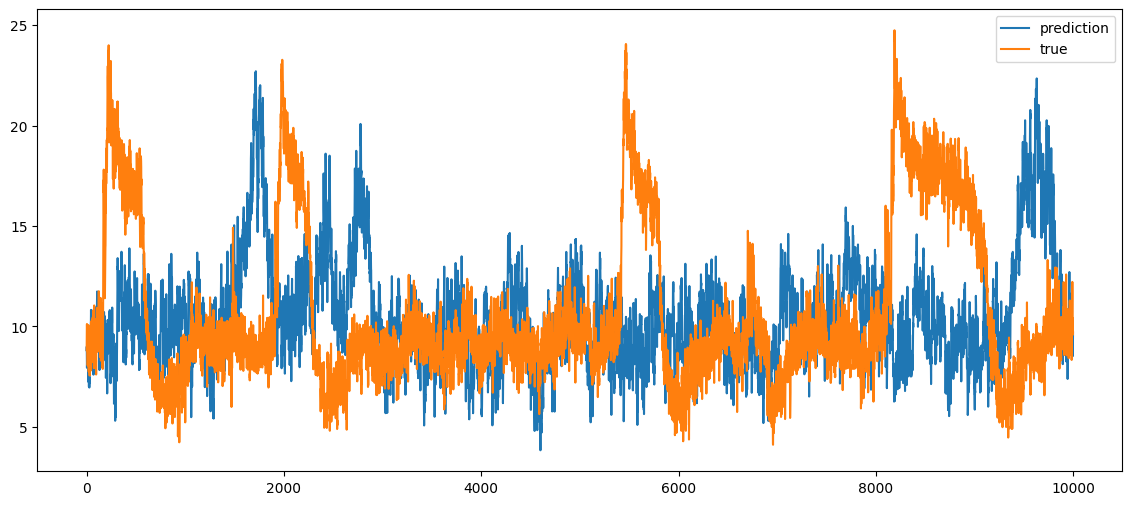

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, preds['AMOC'], label = 'prediction')
plt.plot(x, X_df['AMOC'][start_idx:start_idx+steps], label = 'true')
plt.legend()